In [6]:
import numpy as np
a=np.arange(3,10) #[3,10) 可以指定step=2,每个数差1
s=slice(0,7,2)#索引切片
print(a[s])#打印出来 [3 5 7 9]。
print(a)

[3 5 7 9]
[3 4 5 6 7 8 9]


In [ ]:
#普通索引和布尔索引
import numpy as np
a=np.array([[1,2.5,-3],[4,0.8,-2],[0,5.3,8]])
print(a)
print(a[1,...])#行[ 4.   0.8 -2. ]  ...等同于:
print(a[:,1:])#列 [[ 2.5 -3. ][ 0.8 -2. ][ 5.3  8. ]] 第1-后有列 
print(a[1:3,2])#[-2.  8.]
print(a[0][0]) #1.0
print(a[1,...][2])#这种是取第一行的数据,然后取第2个 -2
print(a[(a>2)&(a<12)]) #[2.5 4.  5.3 8. ]
mask=a>2;print(mask)#[[False  True False][ True False False][False  True  True]]

[[ 1.   2.5 -3. ]
 [ 4.   0.8 -2. ]
 [ 0.   5.3  8. ]]
[ 4.   0.8 -2. ]
[[ 2.5 -3. ]
 [ 0.8 -2. ]
 [ 5.3  8. ]]
[-2.  8.]
[4.  5.3]
1.0
-2.0
[2.5 4.  5.3 8. ]
[[False  True False]
 [ True False False]
 [False  True  True]]


In [8]:
#花式索引

arr = np.array([10, 20, 30, 40, 50, 60])
# 使用整数列表索引
indices = [0, 2, 4]
print(arr[indices])  # [10 30 50]


# 二维花式索引
arr2d = np.arange(12).reshape(3, 4)
#arr2d [[ 0  1  2  3]
#       [ 4  5  6  7]
#       [ 8  9 10 11]]
print(arr2d[[0,2],:])  # 取第0行和第二行
# [[ 0  1  2  3]
#  [ 8  9 10 11]]
# 取指定行和列的交点
print(arr2d[[0, 2], [1, 3]])  # [1 11] (arr[0,1] 和 arr[2,3])
# 使用 np.ix_() 取矩形区域
print(arr2d[np.ix_([0, 2], [1, 3])])
# [[ 1  3]
#  [ 9 11]]

[10 30 50]
[[ 0  1  2  3]
 [ 8  9 10 11]]
[ 1 11]
[[ 1  3]
 [ 9 11]]


In [ ]:
import numpy as np
arr=np.random.uniform(low=-5,high=4,size=(5,5))
round1=np.round(arr,3)  #截取小数点后3位

print(round1[1,round1[1,:]>0.5])   #第一行>0.5的元素
print(round1[:,2]>0.5)   #第2列的所有元素>0.5的真值 [False  True  True  True False]
print(round1[round1[:,2]>0.5])  #然后选择为true的元素及行
print(f"round1矩阵:\n{round1}")

[1.069 3.299 0.523]
[False  True  True  True False]
[[ 1.069 -4.354  3.299  0.523 -4.947]
 [-0.156  2.45   0.857  2.723 -2.479]
 [-0.916  1.002  2.193 -4.298 -4.423]]
round1矩阵:
[[ 3.483  1.    -0.585 -3.081  0.318]
 [ 1.069 -4.354  3.299  0.523 -4.947]
 [-0.156  2.45   0.857  2.723 -2.479]
 [-0.916  1.002  2.193 -4.298 -4.423]
 [-2.143 -0.793 -3.81  -0.159 -0.323]]


In [ ]:
import numpy as np
arr=np.array([[1,2,3],[4,5,6]])
print(arr.shape)  #(2,3)
print(arr.ndim) #维度是2。维度0是行，维度1是列 维度0相当于[] #维度1 括号位于上下
print(np.sum(arr,axis=0)) #{5,7,9} axis=0会跨行,每列一个值
print(np.sum(arr,axis=1)) #[6,15]

(2, 3)
2
[5 7 9]
[ 6 15]
[[1 2]
 [3 4]]


In [ ]:
#求三个维度
import numpy as np
arr1=np.array([[[1,2],[3,4]],[[5,6],[7,8]]])
print(arr1)#z轴0是最外层,跨层。轴1是中间层,跨行。轴2最内层跨列
print(np.sum(arr1,axis=0)) #[[ 6  8][10 12]]
print(np.sum(arr1,axis=1))#[[4 6][12 14]]
print(np.sum(arr1,axis=2)) #[[3 7][11 15]]

[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
[[ 6  8]
 [10 12]]
[[ 4  6]
 [12 14]]
[[ 3  7]
 [11 15]]


In [ ]:
arr=[1,1.6,2.5,'zhang']
print(type(arr[3]))  #<class 'str'>
print(arr1.dtype)   #int32 float64 类型

<class 'str'>
int64


In [ ]:
#对比ndarray和list的矩阵乘积
import numpy as np
import time
arr1=np.random.rand(10)#10000000
lst=arr1.tolist()
#1.向量化变为原来2倍。
start=time.time()
arr1=arr1*2
end=time.time()
print(f"向量化用时: {end - start:.4f}秒") #向量化用时: 0.0177秒
#2.列表变为原来2倍
start=time.time()
#修改副本
for x in lst: #强化for循环,这里的x只是副本,不会修改原数组值。不是引用
    x=x*2  
#修改原件
for i in range(len(lst)):#方式1
    lst[i]*=2          
lst=[x*2 for x in lst] #方式2
end=time.time()
print(f"向量化用时: {end - start:.4f}秒") #向量化用时: 0.5567秒 只算一种方式
#向量化:内层循环,一次操作整个数组,无Python解释器开销
#Python循环:每个元素都要经过Python解释器（类型检查、方法查找等）

向量化用时: 0.0000秒
[1.10734564 0.94677287 0.20899992 0.99572059 1.73957469 1.46314853
 0.30397369 1.50854704 0.60567259 0.85193614]
[2.214691270942736, 1.8935457478512405, 0.4179998434926433, 1.991441173914251, 3.479149371014574, 2.9262970553509313, 0.6079473778765254, 3.0170940740958, 1.2113451774061423, 1.703872280949466]
向量化用时: 0.0000秒


In [ ]:
#对比ndarray和list的求根操作
import numpy as np
import time
import math
arr1=np.random.uniform(low=0,high=5,size=10000000)
lst=arr1.tolist()
print(arr1)
#ndarray
start=time.time()
sqart_arr=np.sqrt(arr1)
end=time.time()
print(sqart_arr)
print(f"向量化用时:{end - start:.4f}秒")#向量化用时:0.0034秒
#list
start=time.time()
for i in range(len(lst)): #循环求根
    lst[i]=math.sqrt(lst[i])
end=time.time()
print(f"向量化用时:{end - start:.4f}秒")#向量化用时:0.1487秒

[1.10566926 1.91862316 3.06199679 ... 1.11990906 2.57054326 0.86705551]
[1.05150809 1.38514373 1.74985622 ... 1.05825756 1.60329138 0.93115815]
向量化用时:0.0296秒
向量化用时:1.3963秒


In [ ]:
#广播相加
import numpy as np
#手动实现形状(3,1)和(3,)数组的广播相加
a=np.array([[1],[2],[3]]) #形状(3,1) 3*1
b=np.array([4,5,6]) #形状(3,) 1*3
#广播是numpy对不同形状的数组进行数值计算的方式。如果两个数组a和b形状相同,
#即满足a.shape==b.shape,那么a*b的结果就是a与b数组对应位相乘。形状不同,numpy触发广播。
#1 1 1 4 5 6
#2 2 2 4 5 6
#3 3 3 4 5 6
print(a+b) #[[5 6 7] [6 7 8] [7 8 9]]

[[5 6 7]
 [6 7 8]
 [7 8 9]]


In [ ]:
#手写矩阵乘法
import numpy as np
def matrix_mul(A,B):
    m,n=A.shape    #行,列
    n1,p=B.shape   #行,列
    result=np.zeros([m,p])
    if(n!=n1):
        raise ValueError("矩阵形状不匹配:Ａ列数不等于Ｂ行数")
#使用三层循环手写,第一层和第二层取最终矩阵的行和列。然后第三层算每次相乘的值
    for i in range(m):
        for j in range(p):
            for k in range(n):
                result[i,j]+=A[i,k]*B[k,j]
    return result
A=np.array([[1,2],[3,4]])
B=np.array([[5,6],[7,8]])
print(matrix_mul(A,B))
#numpy计算矩阵成绩
print(np.dot(A,B)) #[[19 22][43 50]]
#np.dot 调用高度优化的BLAS库。手写三重循环在python解释器李逐元素运算,每个乘法有python对象开销。相差100-200倍

[[19. 22.]
 [43. 50.]]
[[19 22]
 [43 50]]


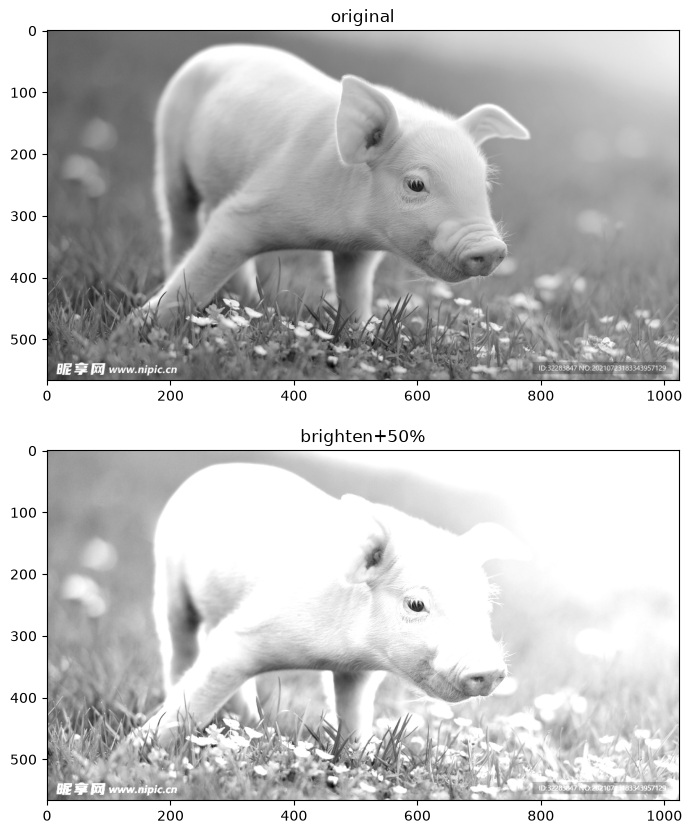

In [ ]:
#用NumPy模拟灰度图亮度增加50%
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
#img_rgb=plt.imread('pig.jpg') #shape:（height,width,3）
#img=np.dot(img_rgb[...,:3],[0.2999,0.587,0.114])
img=Image.open('pig.jpg').convert('L') #使用这个直接转为灰度
img = np.array(img) #转换为数组
img= img.astype(np.float32) #转float防止溢出
img*=1.5
img_bri=np.clip(img,0,255) #所有小于0的变成0，大于255的变成255。
img_bri=img_bri.astype(np.uint8) 
plt.figure(figsize=(20, 10))#创建宽20高10的画布
plt.subplot(2, 1, 1)#将画布分为1行,2列,当前选中第一个
plt.imshow(img, cmap='gray')#显示图像 ciridis 蓝黄，hot
plt.title("original")
plt.subplot(2, 1, 2)
plt.imshow(img_bri, cmap='gray')
plt.title("brighten+50%")
plt.show()  #显示整个画布

原始图像矩阵:
[[104  29 148 244]
 [ 93   7  95 213]
 [191 122  20 105]
 [165  17 231  44]]
亮度增加50%的矩阵:
[[156  43 222 255]
 [139  10 142 255]
 [255 183  30 157]
 [247  25 255  66]]


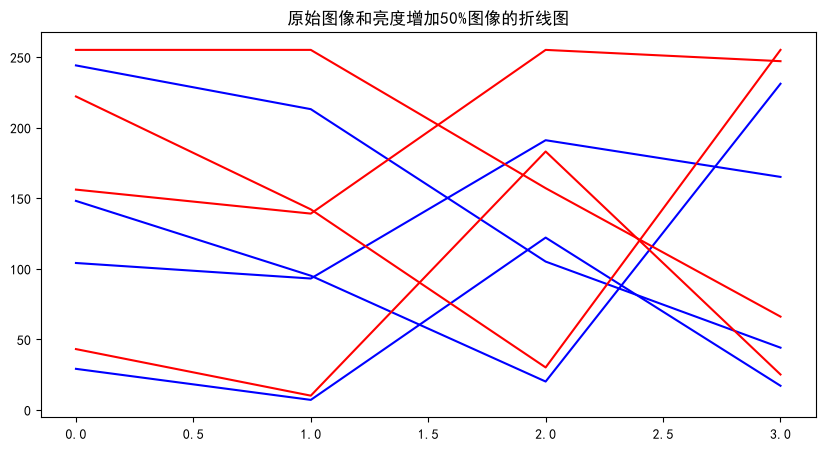

In [17]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

img=np.random.randint(0,256,(4,4))
print(f"原始图像矩阵:\n{img}")
img=img.astype(np.float32)
img_bri=np.clip(img*1.5,0,255).astype(np.uint8)
plt.figure(figsize=(10,5))
print(f"亮度增加50%的矩阵:\n{img_bri}")
plt.title("原始图像和亮度增加50%图像的折线图",loc="center")
plt.plot(img,'b-')
plt.plot(img_bri,'r')

In [ ]:
#用代码验证视图(view)和副本(copy)的区别
import numpy as np
arr=np.arange(10)
print("原始 arr:",arr)
slice_method=arr[2:6]
slice_method[0]=999
print("f修改slice_method后arr:{arr}")
#视图是原始数组的引用，它共享相同的内存数据。切片,reshape,transpose,ravel 会得到视图
print(slice_method.base)#[  0   1 999   3   4   5   6   7   8   9]
arr1=arr[::2].copy()#强制将切片换为副本
arr1[0]=35
print(arr)
#-----上面切片,及视图。下面索引
#花式索引
arr=np.arange(10)   #重新定义arr
fancy_method=arr[[2,3,4,5]];fancy_method[0]=999
print("修改fancy_method后arr",arr)
#布尔索引方式
arr=np.arange(10);
bool_method=arr[arr>5];bool_method[0]=999
print("修改bool_method后arr",arr)

原始 arr: [0 1 2 3 4 5 6 7 8 9]
修改slice_method后arr: [  0   1 999   3   4   5   6   7   8   9]
[  0   1 999   3   4   5   6   7   8   9]
[  0   1 999   3   4   5   6   7   8   9]
修改fancy_method后arr [0 1 2 3 4 5 6 7 8 9]
修改bool_method后arr [0 1 2 3 4 5 6 7 8 9]


In [37]:
#用pandas读csv，填充缺失值，按某列分组聚合
import pandas as pd
import numpy as np
#CSV代表Comma Separated Values,CSV是一种存文本文件,用于存储数据和电子表格信息 comma逗号
#示例数据（模拟学生成绩表）
data = {
    '班级': ['A', 'A', 'B', 'B', 'C', 'C', 'A', 'B', 'C'],
    '姓名': ['张三', '李四', '王五', '赵六', '小明', '小红', '小刚', '小丽', '小华'],
    '数学成绩': [85, 92, 78, np.nan, 88, 76, 94, np.nan, 82]
}
#np.nan用来表示缺失值和无效数据
df=pd.DataFrame(data)    #dataframe是pandas核心数据结构，类似二维表格
print("原始数据:\n",df)
print("非空值统计:\n",df.info())#查看每列非空值
print("缺失值统计:\n",df.isnull().sum())

#用平均值填充缺失值
df['数学成绩']=df['数学成绩'].fillna(df['数学成绩'].mean()) #中位数median(),mean()平均值
df['数学成绩']=df['数学成绩'].fillna(df.groupby('班级')['数学成绩'].transform('mean'))  #按班级填充值
print('填充后的数据:\n',df)
df['class_mean']=df.groupby('班级')['数学成绩'].transform('mean')
print(f'增加一列的数据\n{df}')

#按班级分组计算平均值
df=df.sort_values(by='数学成绩',ascending=False)#降序排序
result=df.groupby('班级')['数学成绩'].mean()   #先分组后计算平均值
#transform为原来df增加一个行或者1列。现在增加的这列属性为class_mean.方法为'mean'(均值)。
print('各班平均成绩:\n',result)


原始数据:
   班级  姓名  数学成绩
0  A  张三  85.0
1  A  李四  92.0
2  B  王五  78.0
3  B  赵六   NaN
4  C  小明  88.0
5  C  小红  76.0
6  A  小刚  94.0
7  B  小丽   NaN
8  C  小华  82.0
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   班级      9 non-null      str    
 1   姓名      9 non-null      str    
 2   数学成绩    7 non-null      float64
dtypes: float64(1), str(2)
memory usage: 411.0 bytes
非空值统计:
 None
缺失值统计:
 班级      0
姓名      0
数学成绩    2
dtype: int64
填充后的数据:
   班级  姓名  数学成绩
0  A  张三  85.0
1  A  李四  92.0
2  B  王五  78.0
3  B  赵六  85.0
4  C  小明  88.0
5  C  小红  76.0
6  A  小刚  94.0
7  B  小丽  85.0
8  C  小华  82.0
增加一列的数据
  班级  姓名  数学成绩  class_mean
0  A  张三  85.0   90.333333
1  A  李四  92.0   90.333333
2  B  王五  78.0   82.666667
3  B  赵六  85.0   82.666667
4  C  小明  88.0   82.000000
5  C  小红  76.0   82.000000
6  A  小刚  94.0   90.333333
7  B  小丽  85.0   82.666667
8  C  小华  82.0   82.000000
各班平均成绩:
 班级
A  